<a href="https://colab.research.google.com/github/spannav/project_bigdata/blob/sukie2/Part3_ThaiPBS_Economy_Robot_headlines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ติดตั้งฟอนต์ไทยสำหรับ matplotlib (Tahoma เป็นฟอนต์ Windows ไม่มีใน Colab)
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf -O thsarabunnew-webfont.ttf

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.font_manager.fontManager.addfont("thsarabunnew-webfont.ttf")
plt.rcParams["font.family"] = "TH Sarabun New"

# Part 3: Data Collection Robot + External Business Insight
### ทีม: ... (กรอกชื่อทีม)

โน้ตบุ๊กนี้ตัดเฉพาะส่วนที่ต้องใช้งานจริงสำหรับ **Part 3** โดยตั้งค่าให้ใช้กับ **Thai PBS หมวดเศรษฐกิจ (เฉพาะหัวข้อข่าวทอง/น้ำมัน)** ด้วยวิธี **Web Robot**


### 3.1 แหล่งข้อมูลและวิธีเก็บ

* **แหล่งข้อมูล:** หน้ารวมข่าวหมวดเศรษฐกิจของ Thai PBS — https://www.thaipbs.or.th/news/categories/economy (กรองเฉพาะหัวข้อข่าวที่เกี่ยวกับทอง/น้ำมัน)
* **คำถาม:** ช่วงนี้ราคาทองกับน้ำมันผันผวนแค่ไหน และสื่อรายงานผลกระทบต่อค่าครองชีพคนทั่วไปบ่อยแค่ไหน
* **การตัดสินใจที่ข้อมูลนี้ช่วยได้:** ทีม content/การตลาดของแอปการเงินส่วนบุคคลควรสร้างระบบแจ้งเตือน/คอนเทนต์อัตโนมัติเรื่องผลกระทบราคาทอง-น้ำมันต่อผู้ใช้หรือไม่ และควรปล่อยตอนไหนถึงจะคุ้ม
* **ผู้ใช้ผลวิเคราะห์:** ทีม content/การตลาดของแอปการเงินส่วนบุคคล (เช่น แอปธนาคาร แอปออมเงิน) ที่อยากรู้ว่าควรทำคอนเทนต์อธิบายผลกระทบราคาทอง-น้ำมันตอนไหนถึงจะคุ้ม
* **1 record คือ:** 1 **หัวข้อข่าว** (headline) ที่เกี่ยวกับราคาทอง/น้ำมัน ที่ปรากฏในหน้ารวมข่าวหมวดเศรษฐกิจ — robot เก็บจากหน้ารวมข่าวโดยตรง **ไม่ได้เปิดอ่านเนื้อหาบทความ**
* **วิธีเก็บ:** Web Robot / Crawler (วนดึงหน้ารวมข่าวหลายหน้า เคารพ robots.txt และหน่วงเวลาระหว่าง request)
* **field ที่เก็บ:** url, title (หัวข้อข่าว), pub_date (วันที่จากหน้ารวมข่าว), mentions_impact (หัวข้อพูดถึงผลกระทบผู้บริโภคหรือไม่), fluctuation_count (เฉพาะหัวข้อสรุปราคาทองรายวัน)
* **ข้อจำกัดที่ยอมรับ:** วัดว่าสื่อ "พูดถึงผลกระทบ" จากหัวข้อข่าวเท่านั้น ไม่ได้อ่านเนื้อหาเต็ม จึงอาจต่ำกว่าความจริง (ต้องบอกไว้ใน Insight Card)


#### Step 0 — Setup

เตรียมเครื่องมือก่อนเริ่ม: ติดตั้ง library ที่ใช้จริงใน Part 3 (`requests`, `beautifulsoup4`, `pandas`, `matplotlib`), ตั้ง `RANDOM_SEED` ให้ผลรันซ้ำได้ และตั้งฟอนต์ไทยให้กราฟแสดงตัวอักษรไทยได้ (เซลล์ฟอนต์อยู่บนสุดของไฟล์)


In [ ]:
# ===== Setup =====
# ติดตั้งเฉพาะ library ที่ใช้จริงใน Part 3 นี้ (ไม่รวม library ของ Part 1/2)
!pip install -q requests beautifulsoup4 pandas matplotlib

import re
import time
import json
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlparse, urldefrag
from urllib.robotparser import RobotFileParser

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

%matplotlib inline


#### Step 1 — กำหนดแหล่งข้อมูลและสิ่งที่ต้องการเก็บ

กำหนดให้ชัดก่อนว่า robot จะไปเก็บอะไรจากที่ไหน

* `LISTING_URL` / `LISTING_PAGES` = หน้ารวมข่าวหมวดเศรษฐกิจของ Thai PBS (หน้าแรก + archive หน้า 2–41) เป็นทางเข้าไปเก็บหัวข้อข่าว
* `ARTICLE_PATH_PATTERN` = รูปแบบ URL ที่ถือว่าเป็นข่าวจริง (`/news/content/<เลข>`) ใช้แยกลิงก์ข่าวออกจากเมนูและหน้าหมวดอื่น ๆ
* `THAI_MONTHS` = ตารางแปลงเดือนไทย (ก.ย. → 9) ไว้แปลงวันที่
* `GOLD_OIL_KEYWORDS` = คำที่ใช้คัดเฉพาะหัวข้อข่าวทอง/น้ำมัน
* `IMPACT_KEYWORDS` = คำที่ถือว่าหัวข้อข่าว "พูดถึงผลกระทบต่อผู้บริโภค"
* `DELAY` = เวลาพักระหว่างการเรียกแต่ละหน้า เพื่อไม่ยิง request ถี่เกินไป

**1 record ของงานนี้ = 1 หัวข้อข่าว** ที่เก็บจากหน้ารวมข่าวโดยตรง (ไม่ได้เปิดเข้าไปอ่านเนื้อหาบทความ)


In [ ]:
# ===== Step 1: ตั้งค่า =====
BASE_URL = "https://www.thaipbs.or.th"
LISTING_URL = "https://www.thaipbs.or.th/news/categories/economy"

# หน้ารวมข่าวหมวดเศรษฐกิจมี 41 หน้า (หน้าสุดท้ายย้อนไปถึงราวต้น เม.ย. 2569)
LISTING_PAGES = [LISTING_URL] + [
    f"{LISTING_URL}/archive?page={i}" for i in range(2, 42)
]

# ใช้ระบุว่าลิงก์ไหนคือ "หัวข้อข่าว" (ไม่ได้เปิดเข้าไปอ่านบทความ)
ARTICLE_PATH_PATTERN = r"^/news/content/\d+$"

# เดือนไทย (ใช้แปลงวันที่ในหน้ารวมข่าวและในหัวข้อข่าว)
THAI_MONTHS = {
    "ม.ค.": 1, "ก.พ.": 2, "มี.ค.": 3, "เม.ย.": 4, "พ.ค.": 5, "มิ.ย.": 6,
    "ก.ค.": 7, "ส.ค.": 8, "ก.ย.": 9, "ต.ค.": 10, "พ.ย.": 11, "ธ.ค.": 12,
}
THAI_MONTH_PATTERN = "|".join(re.escape(m) for m in THAI_MONTHS)

# คำสำคัญไว้กรองว่าหัวข้อข่าวไหนเกี่ยวกับทอง/น้ำมัน
GOLD_OIL_KEYWORDS = ["ทอง", "น้ำมัน", "ดีเซล", "เบนซิน", "แก๊สโซฮอล์", "LPG", "NGV",
                     "กบน", "พลังงาน", "เชื้อเพลิง", "ก๊าซ", "แก๊ส"]

# คำสำคัญไว้เช็คว่า "หัวข้อข่าว" พูดถึงผลกระทบต่อผู้บริโภค/ค่าครองชีพหรือไม่
IMPACT_KEYWORDS = ["ค่าครองชีพ", "ผู้บริโภค", "กำลังซื้อ", "ปากท้อง", "ประชาชน", "ราคาสินค้า",
                   "ของแพง", "ค่าใช้จ่าย", "รายจ่าย", "ต้นทุน", "กระเป๋าเงิน", "ลดภาระ"]

DELAY = 1.5             # วินาที พักระหว่าง request แต่ละครั้ง ไม่ยิงถี่เกินไป
BOT_USER_AGENT = "Part3-CourseProject-Bot/1.0 (educational use)"

session = requests.Session()
session.headers.update({"User-Agent": BOT_USER_AGENT})


def is_gold_oil_news(text):
    return any(kw in text for kw in GOLD_OIL_KEYWORDS)


def mentions_consumer_impact(text):
    return any(kw in text for kw in IMPACT_KEYWORDS)


#### Step 2 — ทำความสะอาด URL และตรวจ `robots.txt`

* `normalize_url()` ตัดส่วน `#...` (fragment) และ `/` ท้าย URL ออก เพื่อไม่ให้ URL เดียวกันที่เขียนต่างกันถูกนับซ้ำ
* `robots_allowed()` ตรวจ `robots.txt` ก่อนเข้าแต่ละหน้า ถ้าไม่อนุญาตให้ bot เข้า ต้อง **เปลี่ยนแหล่งข้อมูล** ไม่ใช่หาวิธีหลบ (ถ้าอ่าน `robots.txt` ไม่ได้ จะถือว่าไม่อนุญาตไว้ก่อนเพื่อความปลอดภัย)


In [ ]:
# ===== Step 2: normalize URL + ตรวจ robots.txt =====
_robots_cache = {}

def normalize_url(url):
    """ตัด #fragment ออกจาก URL เพื่อไม่ให้หน้าเดียวกันถูกนับซ้ำ"""
    clean_url, _ = urldefrag(url)
    return clean_url.rstrip("/")


def robots_allowed(url, user_agent=BOT_USER_AGENT):
    """คืน True เมื่อ robots.txt อนุญาตให้ bot เข้าถึง URL"""
    p = urlparse(url)
    root = f"{p.scheme}://{p.netloc}"

    if root not in _robots_cache:
        rp = RobotFileParser()
        rp.set_url(urljoin(root, "/robots.txt"))
        try:
            rp.read()
        except Exception:
            # อ่าน robots.txt ไม่ได้ ให้ปลอดภัยไว้ก่อนโดยถือว่าไม่อนุญาต
            _robots_cache[root] = None
            return False
        _robots_cache[root] = rp

    rp = _robots_cache[root]
    if rp is None:
        return False
    return rp.can_fetch(user_agent, url)


#### Step 3 — เข้า “หน้ารวมข่าว” เพื่อเก็บหัวข้อข่าวและวันที่

Robot วนเปิดหน้ารวมข่าวทีละหน้า แล้วในแต่ละหน้าทำดังนี้

1. ดู `<a href="...">` ทุกลิงก์ กรองให้เหลือเฉพาะ URL ที่ตรงรูปแบบข่าว (`/news/content/<เลข>`)
2. ดึง **หัวข้อข่าว** จากลิงก์นั้น (`pick_title`)
3. หา **วันที่** จากการ์ดข่าวใบเดียวกัน (`find_date_text`) ซึ่งเว็บแสดง 2 แบบ คือ `"10 ชั่วโมงที่แล้ว"` และ `"27 ก.ย. 69"` แล้วแปลงเป็นวันที่จริง (`parse_listing_date`)
4. เก็บเป็น 1 record ต่อ 1 URL (URL ซ้ำจะถูกเขียนทับ ไม่นับซ้ำ)

ข้อควรรู้: วันที่แบบ "N ชั่วโมงที่แล้ว" จะถูกแปลงโดยอิงเวลาตอนที่รัน จึงควรเก็บข้อมูลแล้วบันทึกเป็น `corpus.jsonl` ไว้ ไม่ต้องรันเก็บใหม่ทุกครั้ง

ขั้นนี้ **ยังไม่ได้เปิดอ่านบทความ** และถ้าหน้าไหนเจอ 0 หัวข้อ โค้ดจะพิมพ์ข้อมูลช่วยดีบั๊ก (⚠️) ออกมาให้


In [ ]:
# ===== Step 3: เก็บ "หัวข้อข่าว" + วันที่ จากหน้ารวมข่าวโดยตรง (ไม่เปิดอ่านบทความ) =====

# วันที่ในหน้ารวมข่าวมี 2 แบบ: "10 ชั่วโมงที่แล้ว" (ข่าวใหม่) และ "27 ก.ย. 69" (ข่าวเก่ากว่า)
DATE_TEXT_RE = re.compile(
    rf"(\d+\s*(?:นาที|ชั่วโมง|วัน)ที่แล้ว|\d{{1,2}}\s*(?:{THAI_MONTH_PATTERN})\s*\d{{2,4}})"
)


def clean_text(s):
    return re.sub(r"\s+", " ", s or "").strip()


def parse_listing_date(date_text):
    """แปลงข้อความวันที่ในหน้ารวมข่าวเป็น date เช่น '10 ชั่วโมงที่แล้ว' หรือ '27 ก.ย. 69'"""
    if not date_text:
        return None

    m = re.match(r"(\d+)\s*(นาที|ชั่วโมง|วัน)ที่แล้ว", date_text)
    if m:
        n, unit = int(m.group(1)), m.group(2)
        delta = {"นาที": pd.Timedelta(minutes=n),
                 "ชั่วโมง": pd.Timedelta(hours=n),
                 "วัน": pd.Timedelta(days=n)}[unit]
        return (pd.Timestamp.now(tz="Asia/Bangkok") - delta).date()

    m = re.match(rf"(\d{{1,2}})\s*({THAI_MONTH_PATTERN})\s*(\d{{2,4}})", date_text)
    if m:
        day, month, year = int(m.group(1)), THAI_MONTHS[m.group(2)], int(m.group(3))
        if year < 100:          # ปีแบบย่อ เช่น 69 -> 2569
            year += 2500
        try:
            return pd.Timestamp(year=year - 543, month=month, day=day).date()
        except ValueError:
            return None
    return None


def article_urls_in(node, base_url):
    """คืน set ของ url ข่าวทั้งหมดที่อยู่ใน node นี้"""
    urls = set()
    for x in node.find_all("a", href=True):
        u = normalize_url(urljoin(base_url, x["href"]))
        if re.match(ARTICLE_PATH_PATTERN, urlparse(u).path):
            urls.add(u)
    return urls


def pick_title(anchors):
    """เลือกหัวข้อข่าวจากลิงก์ทั้งหมดที่ชี้ไปข่าวเดียวกัน"""
    # 1) ลิงก์ที่อยู่ใน/ครอบ <h2>,<h3> คือหัวข้อข่าวตัวจริง (ไม่ขึ้นกับว่า a อยู่ใน h3 หรือ h3 อยู่ใน a)
    for a in anchors:
        if a.find_parent(["h2", "h3"]) is not None or a.find(["h2", "h3"]) is not None:
            t = clean_text(a.get_text(" ", strip=True))
            if t:
                return t
    # 2) title attribute ของลิงก์ (เว็บนี้ใส่หัวข้อข่าวไว้ตรงนี้ด้วย แม้ลิงก์ที่เป็นรูปภาพ)
    for a in anchors:
        t = clean_text(a.get("title", ""))
        if t:
            return t
    # 3) ข้อความในลิงก์ที่สั้นที่สุด (ตัวที่ยาวมักมีข้อความเวลาติดมาด้วย)
    texts = [clean_text(a.get_text(" ", strip=True)) for a in anchors]
    texts = [t for t in texts if t]
    return min(texts, key=len) if texts else ""


def find_date_text(anchors, title, url, base_url):
    """หาข้อความวันที่ของการ์ดข่าวใบนี้ โดยไล่ขึ้นไปหา "กล่อง" ที่มีข่าวเดียว (ไม่หยิบของการ์ดข้างเคียง)"""
    for a in anchors:
        node = a
        for _ in range(6):
            node = node.parent
            if node is None or node.name in ("body", "html", "[document]"):
                break
            if article_urls_in(node, base_url) != {url}:
                break       # กล่องนี้มีมากกว่า 1 ข่าว = ไม่ใช่การ์ดใบเดียวแล้ว
            text = clean_text(node.get_text(" ", strip=True)).replace(title, "")
            m = DATE_TEXT_RE.search(text)
            if m:
                return m.group(1)
    return ""


def find_headlines(listing_url):
    """คืน dict {url: record} ของทุกหัวข้อข่าวในหน้ารวมข่าวหน้านี้"""
    if not robots_allowed(listing_url):
        raise PermissionError(f"robots.txt ไม่อนุญาตให้เข้า: {listing_url}")

    r = session.get(listing_url, timeout=20)
    r.raise_for_status()
    soup = BeautifulSoup(r.text, "html.parser")

    # รวบรวมทุก <a> ที่เป็นลิงก์ข่าว แล้วจัดกลุ่มตาม url
    anchors_by_url = {}
    for a in soup.find_all("a", href=True):
        url = normalize_url(urljoin(listing_url, a["href"]))
        if re.match(ARTICLE_PATH_PATTERN, urlparse(url).path):
            anchors_by_url.setdefault(url, []).append(a)

    found = {}
    for url, anchors in anchors_by_url.items():
        title = pick_title(anchors)
        if not title:
            continue
        date_text = find_date_text(anchors, title, url, listing_url)
        found[url] = {
            "url": url,
            "title": title,
            "date_text": date_text,
            "pub_date": parse_listing_date(date_text),
            "category": "เศรษฐกิจ",
        }

    # ถ้าหน้าไหนเจอ 0 หัวข้อ ให้พิมพ์ข้อมูลช่วยดีบั๊กออกมา (พิมพ์ครั้งเดียว)
    if not found and not getattr(find_headlines, "_warned", False):
        find_headlines._warned = True
        print("⚠️ ไม่เจอหัวข้อข่าวในหน้านี้ | <a> ทั้งหมด =", len(soup.find_all("a")),
              "| <h3> =", len(soup.find_all("h3")), "| ความยาว HTML =", len(r.text))
        print("   ตัวอย่างเนื้อหาที่ robot เห็น:", clean_text(soup.get_text(" ", strip=True))[:200])
    return found


all_headlines = {}

for page_url in LISTING_PAGES:
    try:
        items = find_headlines(page_url)
        all_headlines.update(items)
        n_match = sum(1 for v in all_headlines.values() if is_gold_oil_news(v["title"]))
        print(f"{page_url} -> พบ {len(items)} หัวข้อ (สะสมทั้งหมด {len(all_headlines)} | ทอง/น้ำมัน {n_match})")
    except PermissionError as e:
        print("ข้าม (robots.txt ไม่อนุญาต):", e)
    except Exception as e:
        print("ERROR:", page_url, "-", e)
    time.sleep(DELAY)

n_no_date = sum(1 for v in all_headlines.values() if v["pub_date"] is None)
print(f"\nหัวข้อข่าวทั้งหมดที่เก็บได้: {len(all_headlines)} | อ่านวันที่ไม่ได้: {n_no_date}")


https://www.thaipbs.or.th/news/categories/economy -> พบ 24 หัวข้อ (สะสมทั้งหมด 24 | ทอง/น้ำมัน 6)
https://www.thaipbs.or.th/news/categories/economy/archive?page=2 -> พบ 24 หัวข้อ (สะสมทั้งหมด 48 | ทอง/น้ำมัน 12)
https://www.thaipbs.or.th/news/categories/economy/archive?page=3 -> พบ 24 หัวข้อ (สะสมทั้งหมด 72 | ทอง/น้ำมัน 21)
https://www.thaipbs.or.th/news/categories/economy/archive?page=4 -> พบ 24 หัวข้อ (สะสมทั้งหมด 96 | ทอง/น้ำมัน 28)
https://www.thaipbs.or.th/news/categories/economy/archive?page=5 -> พบ 24 หัวข้อ (สะสมทั้งหมด 120 | ทอง/น้ำมัน 38)
https://www.thaipbs.or.th/news/categories/economy/archive?page=6 -> พบ 24 หัวข้อ (สะสมทั้งหมด 144 | ทอง/น้ำมัน 43)
https://www.thaipbs.or.th/news/categories/economy/archive?page=7 -> พบ 24 หัวข้อ (สะสมทั้งหมด 168 | ทอง/น้ำมัน 52)
https://www.thaipbs.or.th/news/categories/economy/archive?page=8 -> พบ 24 หัวข้อ (สะสมทั้งหมด 192 | ทอง/น้ำมัน 61)
https://www.thaipbs.or.th/news/categories/economy/archive?page=9 -> พบ 24 หัวข้อ (สะสมทั้งหมด 216 | 

#### Step 4 — คัดเฉพาะหัวข้อข่าวที่เกี่ยวกับทอง/น้ำมัน

หน้ารวมข่าวหมวดเศรษฐกิจมีข่าวหลายเรื่อง แต่คำถามของทีมสนใจเฉพาะทอง/น้ำมัน จึงคัดหัวข้อที่มีคำใน `GOLD_OIL_KEYWORDS` และเพิ่ม field `mentions_impact` (True/False) ว่าหัวข้อข่าวนั้นมีคำที่พูดถึงผลกระทบต่อผู้บริโภคหรือไม่

หมายเหตุ: `mentions_impact` ดูจากหัวข้อข่าวเท่านั้น ไม่ได้อ่านเนื้อหาเต็ม จึงอาจต่ำกว่าความจริง (ต้องเขียนเป็นข้อจำกัดใน Insight Card)


In [ ]:
# ===== Step 4: กรองเฉพาะหัวข้อข่าวที่เกี่ยวกับทอง/น้ำมัน =====
rows = []
for v in all_headlines.values():
    if is_gold_oil_news(v["title"]):
        row = dict(v)
        row["mentions_impact"] = mentions_consumer_impact(v["title"])
        rows.append(row)

print(f"หัวข้อข่าวเศรษฐกิจทั้งหมด {len(all_headlines)} | เกี่ยวกับทอง/น้ำมัน {len(rows)} (ก่อน clean)")


หัวข้อข่าวเศรษฐกิจทั้งหมด 958 | เกี่ยวกับทอง/น้ำมัน 303 (ก่อน clean)


In [ ]:
pd.DataFrame(rows)[["title", "pub_date", "mentions_impact"]].tail(5)

,title,pub_date,mentions_impact
298,"""คาลเท็กซ์-บางจาก"" ยืนยันภาครัฐตรวจสอบคลังน้ำม...",2026-04-04,False
299,"กพท.คาดหลังสงกรานต์ ""สายการบิน"" ปรับเที่ยวบินต...",2026-04-04,True
300,พลังงาน เผยราคาน้ำมันโลกพุ่ง แจงกองทุนฯ ติดลบ ...,2026-04-03,False
301,จับตาราคาก๊าซหุงต้มขยับ ผู้ประกอบการชี้อั้นไม่...,2026-04-03,False
302,กบน.ตรึงราคาขายปลีกดีเซล หลังเพิ่มชดเชย B7 ลิต...,2026-04-03,False


`mentions_impact` คือช่องที่บอกว่า หัวข้อข่าวนั้นมีคำที่พูดถึงผลกระทบต่อผู้บริโภคหรือไม่
---

- True = หัวข้อข่าวมีคำอย่างน้อย 1 คำจากลิสต์ IMPACT_KEYWORDS ใน Step 1 (ค่าครองชีพ, ผู้บริโภค, กำลังซื้อ, ปากท้อง, ประชาชน, ราคาสินค้า, ของแพง, ค่าใช้จ่าย, รายจ่าย, ต้นทุน, กระเป๋าเงิน, ลดภาระ)
- False = ไม่มีคำเหล่านี้เลย

### 3.2 ตรวจคุณภาพข้อมูล

รายงานสั้น ๆ เพียงว่า

* พยายามเก็บกี่ record
* ใช้งานได้จริงกี่ record
* ตัด duplicate / missing / สั้นผิดปกติไปเท่าไร
* Final corpus เหลือเท่าไร และครอบคลุมช่วงเวลา/หมวดใด

บันทึกเป็น `corpus.jsonl` หรือ CSV เพื่อไม่ต้องดึงข้อมูลใหม่ทุกครั้ง

> เป้าหมายคือ **อย่างน้อย 200 valid analytical records หลัง clean**


------------------------------

In [ ]:
# ----------------- Your code here -----------------
# =========================
# 3.2 ตรวจคุณภาพข้อมูล
# =========================

# Convert rows to DataFrame
df_news = pd.DataFrame(rows)

# สำรองข้อมูลก่อน clean
df_clean = df_news.copy()

# จำนวนข้อมูลก่อน clean
n_before = len(df_clean)

# --------------------------------------------------
# 1) ตรวจ Missing values
# --------------------------------------------------
required_cols = ["url", "title", "pub_date", "mentions_impact"]

missing_before = df_clean[required_cols].isna().sum()

# ตัด record ที่ไม่มีข้อมูลสำคัญ
df_clean = df_clean.dropna(subset=required_cols)

n_after_missing = len(df_clean)
removed_missing = n_before - n_after_missing


# --------------------------------------------------
# 2) ตรวจ Duplicate
# --------------------------------------------------
duplicate_count = df_clean["url"].duplicated().sum()

# ตัดข่าวที่ URL ซ้ำ โดยให้เก็บ record แรกไว้
df_clean = df_clean.drop_duplicates(subset=["url"], keep="first")

n_after_duplicate = len(df_clean)
removed_duplicate = n_after_missing - n_after_duplicate


# --------------------------------------------------
# 3) ตรวจหัวข้อข่าวที่สั้นผิดปกติ
# --------------------------------------------------
df_clean["title_length"] = df_clean["title"].astype(str).str.strip().str.len()

# กำหนดหัวข้อที่สั้นกว่า 10 ตัวอักษรว่าไม่เหมาะสำหรับการวิเคราะห์
short_title_count = (df_clean["title_length"] < 10).sum()

df_clean = df_clean[df_clean["title_length"] >= 10].copy()

n_final = len(df_clean)
removed_short = n_after_duplicate - n_final


# --------------------------------------------------
# 4) ตรวจช่วงเวลาและหมวดหมู่
# --------------------------------------------------
min_date = df_clean["pub_date"].min()
max_date = df_clean["pub_date"].max()

category_count = df_clean["category"].value_counts()


# --------------------------------------------------
# 5) สร้าง year_month ให้พร้อมสำหรับ 3.3
# --------------------------------------------------
df_clean["year_month"] = pd.to_datetime(
    df_clean["pub_date"], errors="coerce"
).dt.to_period("M")


# --------------------------------------------------
# 6) สรุปผลการตรวจคุณภาพข้อมูล
# --------------------------------------------------
print("========== 3.2 Data Quality Report ==========")

print(f"จำนวนข่าวเศรษฐกิจที่ Robot เก็บได้ทั้งหมด      : 957")
print(f"จำนวนข่าวทอง/น้ำมันก่อน Clean                : {n_before}")

print("\n--- Missing values ---")
print(missing_before)

print(f"\nตัด Missing values ออก                       : {removed_missing} records")

print("\n--- Duplicate ---")
print(f"Duplicate URL ที่พบ                          : {duplicate_count}")
print(f"ตัด Duplicate ออก                            : {removed_duplicate} records")

print("\n--- Short title ---")
print(f"หัวข้อข่าวสั้นกว่า 10 ตัวอักษร               : {short_title_count}")
print(f"ตัดหัวข้อสั้นผิดปกติออก                       : {removed_short} records")

print("\n--- Final corpus ---")
print(f"จำนวนข้อมูลหลัง Clean                         : {n_final}")
print(f"ช่วงเวลาของข้อมูล                             : {min_date} ถึง {max_date}")

print("\n--- Category ---")
print(category_count)

print("\nผ่านเกณฑ์อย่างน้อย 200 valid analytical records:",
      "YES" if n_final >= 200 else "NO")
# บันทึกไฟล์
# with open("corpus.jsonl", "w", encoding="utf-8") as f:
#     for d in rows:
#         f.write(json.dumps(d, ensure_ascii=False) + "\n")
#
# อ่านกลับมาใช้
# corp = pd.read_json("corpus.jsonl", lines=True)
#
# ตัดซ้ำและตัดสั้นเกินไป พร้อมรายงานจำนวนที่ตัด

========== 3.2 Data Quality Report ==========
จำนวนข่าวเศรษฐกิจที่ Robot เก็บได้ทั้งหมด      : 957
จำนวนข่าวทอง/น้ำมันก่อน Clean                : 303

--- Missing values ---
url                0
title              0
pub_date           0
mentions_impact    0
dtype: int64

ตัด Missing values ออก                       : 0 records

--- Duplicate ---
Duplicate URL ที่พบ                          : 0
ตัด Duplicate ออก                            : 0 records

--- Short title ---
หัวข้อข่าวสั้นกว่า 10 ตัวอักษร               : 0
ตัดหัวข้อสั้นผิดปกติออก                       : 0 records

--- Final corpus ---
จำนวนข้อมูลหลัง Clean                         : 303
ช่วงเวลาของข้อมูล                             : 2026-04-03 ถึง 2026-09-30

--- Category ---
category
เศรษฐกิจ    303
Name: count, dtype: int64

ผ่านเกณฑ์อย่างน้อย 200 valid analytical records: YES


In [ ]:
df_clean.groupby(["year_month", "mentions_impact"])

In [ ]:
# ส่งข้อมูลที่ผ่านการ Clean แล้วต่อให้ 3.3
df_news = df_clean.drop(columns=["title_length"]).copy()

print("ข้อมูลที่ส่งต่อให้ 3.3:", len(df_news), "records")
display(df_news.head())

ข้อมูลที่ส่งต่อให้ 3.3: 303 records


,url,title,date_text,pub_date,category,mentions_impact,year_month
0,https://www.thaipbs.or.th/news/content/558932,สรุปราคาทองคำ 30 ก.ย.2569 ปิดตลาด ผันผวน 15 คร...,9 ชั่วโมงที่แล้ว,2026-09-30,เศรษฐกิจ,False,2026-09
1,https://www.thaipbs.or.th/news/content/558842,เปิด 20 ประเทศถือครองทองคำสูงสุด สหรัฐฯ ถือทอง...,29 ก.ย. 69,2026-09-29,เศรษฐกิจ,False,2026-09
2,https://www.thaipbs.or.th/news/content/558805,ทองลุ้นทะลุกรอบขาขึ้น จับตา PCE–จ้างงานสหรัฐฯ,29 ก.ย. 69,2026-09-29,เศรษฐกิจ,False,2026-09
3,https://www.thaipbs.or.th/news/content/558804,ราคา “ทองคำ” เช้านี้ -300 บาท “รูปพรรณ” ขายออก...,29 ก.ย. 69,2026-09-29,เศรษฐกิจ,False,2026-09
4,https://www.thaipbs.or.th/news/content/558776,"สรุปราคาทองคำ 28 ก.ย.2569 ปิดตลาด -1,700 บาท ผ...",28 ก.ย. 69,2026-09-28,เศรษฐกิจ,False,2026-09


--------------------------------------------------------------------

### 3.3 หา Insight

ใช้ **1–2 เทคนิค** ที่เหมาะกับคำถาม เช่น

* frequency / n-gram
* sentiment
* topic
* comparison ระหว่างกลุ่ม
* trend ตามเวลา

สร้างกราฟหรือตารางหลักอย่างน้อย **1 ชิ้น** แล้วตอบว่า

> “จากข้อมูลนี้ ผู้ใช้ผลวิเคราะห์ควรรู้อะไรหรือทำอะไรต่อ?”


###Trend

นำข้อมูลข่าวมาจับกลุ่มรายเดือน (year_month) ตั้งแต่เดือน 2026-04 ถึง 2026-09 เพื่อดูแนวโน้มปริมาณข่าวและสัดส่วนข่าวผลกระทบที่มีการเปลี่ยนแปลงไปตามเวลา (และมีการทำ Comparison ระหว่างกลุ่ม ซ้อนอยู่ด้วย คือเปรียบเทียบระหว่าง ข่าวทั้งหมด กับ ข่าวผลกระทบ)

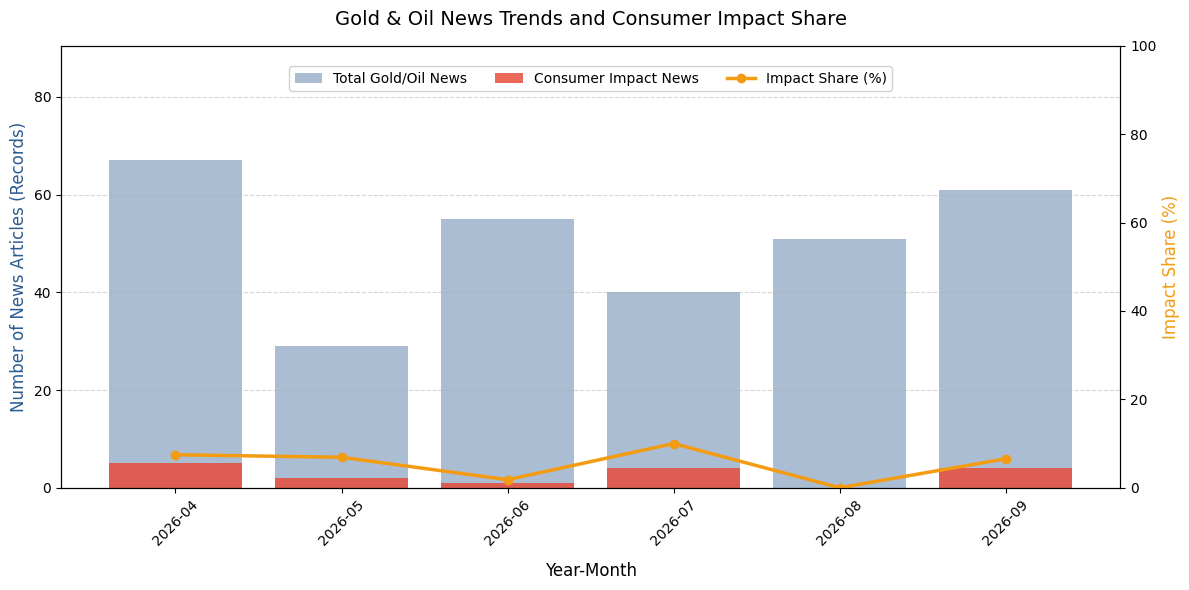

In [ ]:
# =========================================================
# 3.3 Find Insight (Monthly Trend & Impact Keyword Analysis)
# =========================================================
import warnings
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# 1. ปิด Warnings และ Logger ทั้งหมดของ Matplotlib Font Manager
warnings.filterwarnings('ignore')
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
logging.getLogger('matplotlib').setLevel(logging.ERROR)

# 2. ตั้งค่าฟอนต์มาตรฐาน
plt.rcParams['font.family'] = 'sans-serif'

# ---------------------------------------------------------
# Technique 1: Monthly Trend & Comparison Analysis (English)
# ---------------------------------------------------------
monthly_summary = df_news.groupby('year_month').agg(
    total_news=('title', 'count'),
    impact_news=('mentions_impact', 'sum')
).reset_index()

monthly_summary['year_month_str'] = monthly_summary['year_month'].astype(str)
monthly_summary['impact_pct'] = (monthly_summary['impact_news'] / monthly_summary['total_news']) * 100

fig, ax1 = plt.subplots(figsize=(12, 6))

bars1 = ax1.bar(monthly_summary['year_month_str'], monthly_summary['total_news'],
                alpha=0.4, color='#2b5c8f', label='Total Gold/Oil News')
bars2 = ax1.bar(monthly_summary['year_month_str'], monthly_summary['impact_news'],
                alpha=0.85, color='#e74c3c', label='Consumer Impact News')

ax1.set_xlabel('Year-Month', fontsize=12, labelpad=10)
ax1.set_ylabel('Number of News Articles (Records)', fontsize=12, color='#2b5c8f')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# ขยายแกน Y เพิ่มขึ้นเป็น 1.35 เท่า เพื่อเว้นพื้นที่ว่างด้านบนในตัวกราฟ
ax1.set_ylim(0, monthly_summary['total_news'].max() * 1.35)

ax2 = ax1.twinx()
line = ax2.plot(monthly_summary['year_month_str'], monthly_summary['impact_pct'],
                color='#f39c12', marker='o', linewidth=2.5, label='Impact Share (%)')
ax2.set_ylabel('Impact Share (%)', fontsize=12, color='#f39c12')
ax2.set_ylim(0, 100)

# กำหนดชื่อเรื่อง
plt.title('Gold & Oil News Trends and Consumer Impact Share', fontsize=14, pad=15)

# ย้าย Legend ลงมาอยู่ในพื้นที่ว่างด้านบนภายในกรอบกราฟ (ไม่ซ้อน Title และไม่ทับแท่งกราฟ)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.5, 0.97),
           ncol=3, frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

###แกน X (Year-Month)

 แสดงข้อมูลรายเดือนตั้งแต่ เมษายน 2026 (2026-04) ถึง กันยายน 2026 (2026-09)

###Total Gold/Oil News - แกนซ้าย


 แสดงจำนวนข่าวที่เกี่ยวกับทองคำและน้ำมันทั้งหมดในแต่ละเดือน


มีการรายงานข่าวอยู่อย่างสม่ำเสมอเฉลี่ย 30 - 60 ข่าวต่อเดือน โดยเดือนที่มีจำนวนข่าวสูงสุดคือ 2026-09 (ประมาณ 61 ข่าว) และ 2026-04 (ประมาณ 60 ข่าว)

###แท่งสีแดง (Consumer Impact News - แกนซ้าย)

แสดงจำนวนข่าวที่มีการพูดถึง "ผลกระทบต่อผู้บริโภค/ค่าครองชีพ" โดยตรง

มีจำนวนน้อยมากเมื่อเทียบกับข่าวทั้งหมด โดยมีเพียงแค่ 1 - 5 ข่าวต่อเดือน เท่านั้น

###Impact Share (%) - แกนขวา


แสดงสัดส่วนเปอร์เซ็นต์ของข่าวผลกระทบต่อผู้บริโภคเมื่อเทียบกับข่าวทั้งหมด

สัดส่วนข่าวที่พูดถึงผลกระทบต่ำมากอย่างเห็นได้ชัด ไม่เกิน 10% ในทุกๆ เดือน

โดยมีจุดสูงสุดในเดือน 2026-07 (ประมาณ 10%) และลดลงจนเกือบเป็น 0% ในเดือน 2026-08

###Frequency / N-gram

ทำการนับความถี่ของคำสำคัญ (Unigram / Word Frequency) จากหัวข้อข่าว แล้วสกัดออกมาเป็น Top 10 คำสำคัญที่พบบ่อยที่สุด เช่น Gold (168 ครั้ง), Oil (93 ครั้ง), Fluctuated (78 ครั้ง)

In [ ]:
# ---------------------------------------------------------
# Technique 2: Top Keywords Analysis
# ---------------------------------------------------------
keyword_map = {
    "ทอง": "Gold",
    "น้ำมัน": "Oil",
    "ดีเซล": "Diesel",
    "เบนซิน": "Gasoline",
    "ขึ้น": "Price Increase",
    "ลง": "Price Decrease",
    "นิวไฮ": "New High",
    "ทุบสถิติ": "Record High",
    "แพง": "High Cost",
    "ลด": "Reduced",
    "ปรับ": "Adjusted",
    "ผันผวน": "Fluctuated",
    "ตรึง": "Price Cap"
}

found_kw = []
for title in df_news['title']:
    for thai_kw, eng_kw in keyword_map.items():
        if thai_kw in title:
            found_kw.append(eng_kw)

kw_counts = Counter(found_kw).most_common(10)
df_kw = pd.DataFrame(kw_counts, columns=['Keyword', 'Frequency'])

display(df_kw)

,Keyword,Frequency
0,Gold,168
1,Oil,93
2,Fluctuated,78
3,Reduced,59
4,Diesel,46
5,Price Increase,30
6,Price Decrease,29
7,Adjusted,29
8,Gasoline,22
9,Price Cap,6


หมวดหมู่หลัก (Main Topics): คำสำคัญที่พบบ่อยที่สุดคือ Gold (ทองคำ - 168 ครั้ง) และ Oil (น้ำมัน - 93 ครั้ง) ตามมาด้วยประเภทเชื้อเพลิงเฉพาะอย่าง Diesel (ดีเซล - 46 ครั้ง) และ Gasoline (เบนซิน - 22 ครั้ง)

หมวดหมู่การเคลื่อนไหวของราคา (Price Movement): คำส่วนใหญ่ที่ปรากฏในหัวข้อข่าวเน้นอธิบายการผันผวนและการปรับเปลี่ยนตัวเลขราคา ได้แก่:

Fluctuated (ผันผวน): 78 ครั้ง

Reduced (ลดลง): 59 ครั้ง

Price Increase (ปรับขึ้น): 30 ครั้ง

Price Decrease (ปรับลด): 29 ครั้ง / Adjusted (ปรับตัว): 29 ครั้ง

Price Cap (ตรึงราคา): 6 ครั้ง


สื่อเน้นรายงาน "ตัวเลขราคา" มากกว่า "ผลกระทบต่อชีวิตประจำวัน": สำนักข่าวรายงานความเคลื่อนไหวของราคาทองคำและน้ำมันเกือบทุกวัน แต่ส่วนใหญ่เป็นการสรุปตัวเลขสถิติ/การผันผวนรายวัน (เช่น ขึ้น 50 บาท, ปรับลด 30 สตางค์)

มีสัดส่วนข่าวผลกระทบผู้บริโภคน้อยมาก (<10%): หัวข้อข่าวที่ระบุถึงผลกระทบต่อกระเป๋าเงิน ค่าครองชีพ หรือการวางแผนการเงินของประชาชนมีสัดส่วนไม่ถึง 10% ในแต่ละเดือน

โอกาสของแอปพลิเคชันการเงิน (Opportunity for Financial App): ผู้บริโภคเกิดภาวะชินชากับการแจ้งเตือนตัวเลขราคาปกติ แอปการเงินจึงควรเติมเต็มช่องว่างนี้ด้วยการนำเสนอ "Impact-based Content" เช่น การแปลความหมายของราคาน้ำมัน/ทองคำที่เปลี่ยนไป ให้เห็นเป็น "ค่าใช้จ่ายจริงที่กระทบเงินในกระเป๋า" แทนการรายงานเพียงแค่ตัวเลข

## 3.4 Insight Card ของ Part 3

### Insight

สื่อเศรษฐกิจของ Thai PBS รายงานข่าวที่เกี่ยวข้องกับราคาทองคำและราคาน้ำมันอย่างสม่ำเสมอในทุกเดือนที่ศึกษา แต่การสื่อสารในระดับ "หัวข้อข่าว" มุ่งเน้นการรายงานการเปลี่ยนแปลงของราคาเป็นหลัก มากกว่าการสื่อสารผลกระทบที่ผู้บริโภคได้รับโดยตรง โดยสัดส่วนข่าวที่มีลักษณะกล่าวถึงผลกระทบต่อผู้บริโภค (`mentions_impact`) ไม่เคยเกินประมาณ 10% ในทุกเดือนที่สำรวจ

---

### Evidence(หลักฐาน)

จากข้อมูลข่าวทองคำและน้ำมันในช่วงเดือนเมษายน–กันยายน 2569 พบว่า

- มีปริมาณข่าวเฉลี่ยประมาณ 30–60 ข่าวต่อเดือน
- เดือนที่มีข่าวมากที่สุดคือ กันยายน 2569 (ประมาณ 61 ข่าว)
- รองลงมาคือ เมษายน 2569 (ประมาณ 60 ข่าว)

อย่างไรก็ตาม ข่าวที่เข้าเกณฑ์ `mentions_impact` มีเพียงประมาณ 1–5 ข่าวต่อเดือนเท่านั้น และมีสัดส่วนสูงสุดเพียงประมาณ 10% ในเดือนกรกฎาคม 2569 ก่อนลดลงใกล้ 0% ในเดือนสิงหาคม 2569

ผลการวิเคราะห์ Keyword ยังสะท้อนแนวโน้มเดียวกัน โดยคำที่พบมากที่สุด ได้แก่

| Keyword | Frequency |
|----------|----------:|
| ผันผวน | 78 |
| ลด | 59 |
| ปรับขึ้น | 30 |
| ปรับลด | 29 |
| ปรับตัว | 29 |

คำส่วนใหญ่เป็นคำที่ใช้รายงานการเคลื่อนไหวของราคา ขณะที่คำที่สะท้อนผลกระทบต่อผู้บริโภค เช่น ค่าครองชีพ กำลังซื้อ ค่าใช้จ่าย หรือรายได้ ไม่ปรากฏอยู่ในกลุ่มคำสำคัญอันดับต้น ๆ

---

### So What

ผลลัพธ์นี้สะท้อนว่า ผู้ติดตามข่าวเศรษฐกิจได้รับข้อมูลเกี่ยวกับการเปลี่ยนแปลงของราคาทองคำและน้ำมันอย่างต่อเนื่องอยู่แล้ว แต่จากข้อมูลระดับหัวข้อข่าวที่ศึกษา พบว่าการสื่อสารส่วนใหญ่เน้น "เกิดอะไรขึ้นกับราคา" มากกว่า "ผู้บริโภคได้รับผลกระทบอย่างไร"

จึงอาจมองได้ว่ามีช่องว่างด้านการสื่อสาร (Content Gap) สำหรับการแปลข้อมูลเศรษฐกิจให้เชื่อมโยงกับผลกระทบในชีวิตประจำวันของผู้บริโภคได้ชัดเจนยิ่งขึ้น

---

### Action

สำหรับธุรกิจด้านการเงินส่วนบุคคล แอปวางแผนการเงิน หรือแพลตฟอร์มให้ความรู้ทางการเงิน สามารถพัฒนาคอนเทนต์ในรูปแบบ **Impact-Based Content** เพื่อช่วยให้ผู้ใช้งานเข้าใจผลกระทบของการเปลี่ยนแปลงราคาได้ง่ายขึ้น เช่น

- "ราคาทองเพิ่มขึ้น 50 บาทต่อบาททองคำ ส่งผลต่อค่าใช้จ่ายในการซื้อทองอย่างไร"
- "ราคาดีเซลเพิ่มขึ้น 1 บาทต่อลิตร จะเพิ่มค่าเดินทางต่อเดือนประมาณเท่าใด"
- "น้ำมันปรับขึ้นรอบนี้ มีผลต่อค่าขนส่งและค่าครองชีพอย่างไร"

นอกจากนี้ควรเผยแพร่คอนเทนต์ในช่วงที่ปริมาณข่าวเกี่ยวกับราคาทองและน้ำมันเพิ่มสูงขึ้นอยู่แล้ว เช่น ช่วงเดือนเมษายนและกันยายน ซึ่งเป็นช่วงที่ผู้บริโภคมีแนวโน้มให้ความสนใจกับประเด็นดังกล่าวมากเป็นพิเศษ

---

### Confidence Level

**ระดับความมั่นใจ: ปานกลาง (Medium Confidence)**

เนื่องจากแนวโน้มดังกล่าวปรากฏอย่างสม่ำเสมอในข้อมูลตลอดช่วง 6 เดือนที่ศึกษา และได้รับการสนับสนุนจากทั้งการวิเคราะห์ความถี่ของข่าวและการวิเคราะห์ Keyword

อย่างไรก็ตาม ข้อสรุปนี้ยังอ้างอิงจากข้อมูลระดับหัวข้อข่าว (headline) เป็นหลัก จึงควรตีความด้วยความระมัดระวัง

---

## **สิ่งที่ข้อมูลชุดนี้ยังตอบไม่ได้**

### 1. ผู้บริโภครับรู้ผลกระทบจริงหรือไม่

ตัวแปร `mentions_impact` ถูกสร้างจากการตรวจจับคำสำคัญในหัวข้อข่าวเท่านั้น ยังไม่ได้วิเคราะห์เนื้อหาบทความฉบับเต็ม

ดังนั้นจึงไม่สามารถยืนยันได้ว่าบทความทั้งหมดไม่ได้อธิบายผลกระทบต่อผู้บริโภค เพียงแต่ผลกระทบดังกล่าวไม่ได้ถูกสะท้อนอย่างชัดเจนในระดับหัวข้อข่าว

หากต้องการศึกษาประเด็นนี้เพิ่มเติม ควรเก็บเนื้อหาบทความเต็มมาวิเคราะห์ด้วยเทคนิค Sentiment Analysis หรือ Topic Modeling

---

### 2. ความสัมพันธ์กับราคาตลาดจริง

ชุดข้อมูลนี้ไม่มีข้อมูลราคาทองคำและราคาน้ำมันรายวัน

จึงยังไม่สามารถตรวจสอบได้ว่าช่วงที่มีข่าวจำนวนมาก สัมพันธ์กับช่วงที่ราคาผันผวนสูงจริงหรือไม่

หากต้องการวิเคราะห์เพิ่มเติม ควรนำข้อมูลราคาจริงจากตลาดมาเชื่อม (join) กับข้อมูลข่าวเพื่อวิเคราะห์ความสัมพันธ์เชิงเวลา

---

### 3. ภาพรวมของสื่อทั้งตลาด

ข้อมูลที่ใช้มาจาก Thai PBS เพียงแหล่งเดียว

ดังนั้นผลลัพธ์จึงสะท้อนรูปแบบการนำเสนอข่าวของ Thai PBS เท่านั้น และยังไม่สามารถสรุปแทนสื่อเศรษฐกิจทั้งหมดได้

หากต้องการศึกษาภาพรวมของตลาดสื่อ ควรเก็บข้อมูลจากหลายสำนักข่าวเพื่อเปรียบเทียบแนวทางการนำเสนอ

---

### 4. พฤติกรรมผู้ใช้งานจริง

ข้อมูลชุดนี้ไม่สามารถบอกได้ว่าผู้ใช้งานจะตอบสนองต่อคอนเทนต์แบบ Impact-Based มากน้อยเพียงใด

การตัดสินใจลงทุนพัฒนาระบบจริงควรมีข้อมูลเพิ่มเติม เช่น

- User Survey
- Click-through Rate (CTR)
- Engagement Metrics
- A/B Testing